<h1><center> REINFORCEMENT LEARNING </center></h1>
<h2><center> POLICY GRADIENT ALGORITHMS </center></h2>

## 1.SOURCES

https://github.com/firmai/financial-machine-learning

https://colab.research.google.com/drive/1FzLCI0AO3c7A4bp9Fi01UwXeoc7BN8sW

https://pathmind.com/wiki/deep-reinforcement-learning

https://youtu.be/-uXVu0l8guo

## 2.CREATING THE DATA FILE

In [ ]:
! pip install yfinance --upgrade

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.2/59.2 KB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 39.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.2/112.2 KB 12.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.2/111.2 KB 13.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.8/62.8 KB 7.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 KB 15.1 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.25.1
    Uninstalling requests-2.25.1:
      Successfully uninstalled requests-2.25.1
  Attempting uninstall: html5lib
    Found existing installation: html5lib 1.0.1
    Uninstalling html5lib-1.0.1:
      Successfully uninstalled html5lib-1.0.1
  Attempting uninstall: beautifulsoup4
    Found existing installation: beautifulsoup4 4.6.3
   

In [ ]:
## Further  recommendation, test multiple frameworks, see what works better on average.
## Open source RL: https://docs.google.com/spreadsheets/d/1EeFPd-XIQ3mq_9snTlAZSsFY7Hbnmd7P5bbT8LPuMn0/edit#gid=0

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#import tensorflow as tf
import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()
import yfinance as yf

### 2.1.USING YFINANCE FOR LOADING DATA

https://pypi.org/project/yfinance/


In [ ]:
import yfinance as yf
df_full = yf.download("QQQ", start="1995-12-01", end="2022-01-01").reset_index().dropna()

[*********************100%***********************]  1 of 1 completed


In [ ]:
df_full.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,1999-03-10,51.12500,51.156250,50.28125,51.0625,43.906261,5232000
1,1999-03-11,51.43750,51.734375,50.31250,51.3125,44.121223,9688600
2,1999-03-12,51.12500,51.156250,49.65625,50.0625,43.046402,8743600
3,1999-03-15,50.43750,51.562500,49.90625,51.5000,44.282448,6369000
4,1999-03-16,51.71875,52.156250,51.15625,51.9375,44.658627,4905800


## 3.REINFORCEMENT LEARNING

**GO TO JUPUTER VERSION FOR IMAGE**


### 3.1.GENERAL CONCEPTS


Reinforcement learning (RL) is an area of machine learning concerned with how software agents ought to take actions in an environment **in order to maximize some notion of cumulative reward.**


**`Reinforcement learning is one of three basic machine learning paradigms, alongside supervised learning and unsupervised learning`**.

> - Reinforcement learning differs from supervised learning in not needing labelled input/output pairs be presented,
> - Not needing sub-optimal actions to be explicitly corrected.
> - The focus is on finding a balance between exploration (of uncharted territory) and exploitation (of current knowledge).

The environment is typically stated in the form of a Markov decision process (MDP), because many reinforcement learning algorithms for this context utilize dynamic programming techniques.

The main difference between the classical dynamic programming methods and reinforcement learning algorithms is that the latter do not assume knowledge of an exact mathematical model of the MDP and they target large MDPs where exact methods become infeasible.

Reinforcement learning, due to its generality, is studied in many other disciplines, such as game theory, control theory, operations research, information theory, simulation-based optimization, multi-agent systems, swarm intelligence, statistics and genetic algorithms.

**In the operations research and control literature, reinforcement learning is called approximate dynamic programming**, or neuro-dynamic programming. The problems of interest in reinforcement learning have also been studied in the theory of optimal control, which is concerned mostly with the existence and characterization of optimal solutions, and algorithms for their exact computation, and less with learning or approximation, particularly in the absence of a mathematical model of the environment. In economics and game theory, reinforcement learning may be used to explain how equilibrium may arise under bounded rationality.

A reinforcement learning agent interacts with its environment in discrete time steps. At each time t, the agent receives an observation $o_{t}$, which typically includes the reward $r_{t}$. It then chooses an action $a_{t}$ from the set of available actions, which is subsequently sent to the environment. The environment moves to a new state $s_{t+1}$ and the reward $r_{t+1}$ associated with the transition $(s_{t},a_{t},s_{t+1})$ is determined. The goal of a reinforcement learning agent is to collect as much reward as possible. The agent can (possibly randomly) choose any action as a function of the history.

When the agent's performance is compared to that of an agent that acts optimally, the difference in performance gives rise to the notion of regret. In order to act near optimally, the agent must reason about the long term consequences of its actions (i.e., maximize future income), although the immediate reward associated with this might be negative.

Thus, reinforcement learning is particularly well-suited to problems that include a long-term versus short-term reward trade-off. It has been applied successfully to various problems, including robot control, elevator scheduling, telecommunications, backgammon, checkers and Go (AlphaGo).

Two elements make reinforcement learning powerful: the use of samples to optimize performance and the use of function approximation to deal with large environments. Thanks to these two key components, reinforcement learning can be used in large environments in the following situations:

Reinforcement learning can be understood using the concepts of agents, environments, states, actions and rewards, all of which we’ll explain below. Capital letters tend to denote sets of things, and lower-case letters denote a specific instance of that thing; e.g. A is all possible actions, while a is a specific action contained in the set.

Agent: An agent takes actions; for example, a drone making a delivery, or Super Mario navigating a video game. The algorithm is the agent. It may be helpful to consider that in life, the agent is you.1


**Action (A):**

A is the set of all possible moves the agent can make. An action is almost self-explanatory, but it should be noted that agents usually choose from a list of discrete, possible actions. In video games, the list might include running right or left, jumping high or low, crouching or standing still. In the stock markets, the list might include buying, selling or holding any one of an array of securities and their derivatives. When handling aerial drones, alternatives would include many different velocities and accelerations in 3D space.


**Discount factor:**

The discount factor is multiplied by future rewards as discovered by the agent in order to dampen thse rewards’ effect on the agent’s choice of action. Why? It is designed to make future rewards worth less than immediate rewards; i.e. it enforces a kind of short-term hedonism in the agent. Often expressed with the lower-case Greek letter gamma: γ. If γ is .8, and there’s a reward of 10 points after 3 time steps, the present value of that reward is 0.8³ x 10. A discount factor of 1 would make future rewards worth just as much as immediate rewards. We’re fighting against delayed gratification here.


**Environment:**

The world through which the agent moves, and which responds to the agent. The environment takes the agent’s current state and action as input, and returns as output the agent’s reward and its next state. If you are the agent, the environment could be the laws of physics and the rules of society that process your actions and determine the consequences of them.


**State (S):**

A state is a concrete and immediate situation in which the agent finds itself; i.e. a specific place and moment, an instantaneous configuration that puts the agent in relation to other significant things such as tools, obstacles, enemies or prizes. It can the current situation returned by the environment, or any future situation. Were you ever in the wrong place at the wrong time? That’s a state.


**Reward (R):**

A reward is the feedback by which we measure the success or failure of an agent’s actions in a given state. For example, in a video game, when Mario touches a coin, he wins points. From any given state, an agent sends output in the form of actions to the environment, and the environment returns the agent’s new state (which resulted from acting on the previous state) as well as rewards, if there are any. Rewards can be immediate or delayed. They effectively evaluate the agent’s action.
Policy (π): The policy is the strategy that the agent employs to determine the next action based on the current state. It maps states to actions, the actions that promise the highest reward.


**Value (V):**

The expected long-term return with discount, as opposed to the short-term reward R. Vπ(s) is defined as the expected long-term return of the current state under policy π. We discount rewards, or lower their estimated value, the further into the future they occur. See discount factor. And remember Keynes: “In the long run, we are all dead.” That’s why you discount future rewards. It is useful to distinguish


**Q-value or action-value (Q):**

Q-value is similar to Value, except that it takes an extra parameter, the current action a. Qπ(s, a) refers to the long-term return of an action taking action a under policy π from the current state s. Q maps state-action pairs to rewards. Note the difference between Q and policy.


**Trajectory:**

A sequence of states and actions that influence those states. From the Latin “to throw across.” The life of an agent is but a ball tossed high and arching through space-time unmoored, much like humans in the modern world.


**Key distinctions:**

Reward is an immediate signal that is received in a given state, while value is the sum of all rewards you might anticipate from that state. Value is a long-term expectation, while reward is an immediate pleasure. Value is eating spinach salad for dinner in anticipation of a long and healthy life; reward is eating cocaine for dinner and to hell with it. They differ in their time horizons. So you can have states where value and reward diverge: you might receive a low, immediate reward (spinach) even as you move to position with great potential for long-term value; or you might receive a high immediate reward (cocaine) that leads to diminishing prospects over time. This is why the value function, rather than immediate rewards, is what reinforcement learning seeks to predict and control.

Reinforcement learning judges actions by the results they produce. It is goal oriented, and its aim is to learn sequences of actions that will lead an agent to achieve its goal, or maximize its objective function. Here are some examples:

In video games, the goal is to finish the game with the most points, so each additional point obtained throughout the game will affect the agent’s subsequent behavior; i.e. the agent may learn that it should shoot battleships, touch coins or dodge meteors to maximize its score.
In the real world, the goal might be for a robot to travel from point A to point B, and every inch the robot is able to move closer to point B could be counted like points.
Here’s an example of an objective function for reinforcement learning; i.e. the way it defines its goal.

Reinforcement learning differs from both supervised and unsupervised learning by how it interprets inputs. We can illustrate their difference by describing what they learn about a “thing.”

**Unsupervised learning: **

That thing is like this other thing. (The algorithms learn similarities w/o names, and by extension they can spot the inverse and perform anomaly detection by recognizing what is unusual or dissimilar)


**Supervised learning:**

That thing is a “double bacon cheese burger”. (Labels, putting names to faces…) These algorithms learn the correlations between data instances and their labels; that is, they require a labelled dataset. Those labels are used to “supervise” and correct the algorithm as it makes wrong guesses when predicting labels.


**Reinforcement learning:**

Eat that thing because it tastes good and will keep you alive longer. (Actions based on short- and long-term rewards, such as the amount of calories you ingest, or the length of time you survive.) Reinforcement learning can be thought of as supervised learning in an environment of sparse feedback.

**Reinforcement learning is the process of running the agent through sequences of state-action pairs, observing the rewards that result, and adapting the predictions of the Q function to those rewards until it accurately predicts the best path for the agent to take. That prediction is known as a policy**

Reinforcement learning is an **attempt to model a complex probability distribution of rewards** in relation to a very large number of state-action pairs. This is one reason reinforcement learning is paired with, say, a Markov decision process, a method to sample from a complex distribution to infer its properties. It closely resembles the problem that inspired Stan Ulam to invent the Monte Carlo method; namely, trying to infer the chances that a given hand of solitaire will turn out successful.

Reinforcement learning is iterative. In its most interesting applications, it doesn’t begin by knowing which rewards state-action pairs will produce. It learns those relations by running through states again and again, like athletes or musicians iterate through states in an attempt to improve their performance.

### 3.2.NEURAL NETWORKS IN REINFORCEMENT LEARNING

Neural networks are function approximators, which are particularly useful in reinforcement learning when the state space or action space are too large to be completely known.

A neural network can be used to approximate a value function, or a policy function. That is, neural nets can learn to map states to values, or state-action pairs to Q values. Rather than use a lookup table to store, index and update all possible states and their values, which impossible with very large problems, we can train a neural network on samples from the state or action space to learn to predict how valuable those are relative to our target in reinforcement learning.

Like all neural networks, they use coefficients to approximate the function relating inputs to outputs, and their learning consists to finding the right coefficients, or weights, by iteratively adjusting those weights along gradients that promise less error.

In reinforcement learning, convolutional networks can be used to recognize an agent’s state when the input is visual; e.g. the screen that Mario is on, or the terrain before a drone. That is, they perform their typical task of image recognition.

But convolutional networks derive different interpretations from images in reinforcement learning than in supervised learning. In supervised learning, the network applies a label to an image; that is, it matches names to pixels.

At the beginning of reinforcement learning, the neural network coefficients may be initialized stochastically, or randomly. Using feedback from the environment, the neural net can use the difference between its expected reward and the ground-truth reward to adjust its weights and improve its interpretation of state-action pairs.

This feedback loop is analogous to the backpropagation of error in supervised learning. However, supervised learning begins with knowledge of the ground-truth labels the neural network is trying to predict. Its goal is to create a model that maps different images to their respective names.

Reinforcement learning relies on the environment to send it a scalar number in response to each new action. The rewards returned by the environment can be varied, delayed or affected by unknown variables, introducing noise to the feedback loop.

This leads us to a more complete expression of the Q function, which takes into account not only the immediate rewards produced by an action, but also the delayed rewards that may be returned several time steps deeper in the sequence.

https://youtu.be/EHP47tM6ctc

## 4.POLICY GRADIENT REINFORCEMENT ALGORITHM

In order to sopporting this section we go to: **Kapoor,S. (2018) `Policy Gradients in a Nuthshell`**   located at https://towardsdatascience.com/policy-gradients-in-a-nutshell-8b72f9743c5d

Reinforcement Learning (RL) refers to both the learning problem and the sub-field of machine learning which has lately been in the news for great reasons. RL based systems have now beaten world champions of Go, helped operate datacenters better and mastered a wide variety of Atari games. The research community is seeing many more promising results. With enough motivation, let us now take a look at the Reinforcement Learning problem.
Reinforcement Learning is the most general description of the learning problem where the aim is to maximize a long-term objective. The system description consists of an agent which interacts with the environment via its actions at discrete time steps and receives a reward. This transitions the agent into a new state.

A large amount of theory behind RL lies under the assumption of The Reward Hypothesis which in summary states that all goals and purposes of an agent can be explained by a single scalar called the reward. This is still subject to debate but has been fairly hard to disprove yet. More formally, the reward hypothesis is given below
The Reward Hypothesis: That all of what we mean by goals and purposes can be well thought of as the maximization of the expected value of the cumulative sum of a received scalar signal (called reward).
As an RL practitioner and researcher, one’s job is to find the right set of rewards for a given problem known as reward shaping.
The agent must formally work through a theoretical framework known as a Markov Decision Process which consists of a decision (what action to take?) to be made at each state. This gives rise to a sequence of states, actions and rewards known as a trajectory,


Markov Decision Process: A (Discounted) Markov Decision Process (MDP) is a tuple (S,A,R,p,γ), such that

where S_t​, S_(t+1) ​∈ S (state space), A_(t+1) ​∈ A (action space), R_(t+1)​, R_t ​∈ R (reward space), p defines the dynamics of the process and G_t​ is the discounted return.

## 5.POLICY GRADIENT

The objective of a Reinforcement Learning agent is to maximize the “expected” reward when following a policy π. Like any Machine Learning setup, we define a set of parameters θ (e.g. the coefficients of a complex polynomial or the weights and biases of units in a neural network) to parametrize this policy — π_θ​ (also written a π for brevity). If we represent the total reward for a given trajectory τ as r(τ), we arrive at the following definition.

Reinforcement Learning Objective: Maximize the “expected” reward following a parametrized policy

All finite MDPs have at least one optimal policy (which can give the maximum reward) and among all the optimal policies at least one is stationary and deterministic.
Like any other Machine Learning problem, if we can find the parameters θ⋆ which maximize J, we will have solved the task. A standard approach to solving this maximization problem in Machine Learning Literature is to use Gradient Ascent (or Descent). In gradient ascent, we keep stepping through the parameters using the following update rule

Here comes the challenge, how do we find the gradient of the objective above which contains the expectation. Integrals are always bad in a computational setting. We need to find a way around them. First step is to reformulate the gradient starting with the expansion of expectation (with a slight abuse of notation).

The Policy Gradient Theorem: The derivative of the expected reward is the expectation of the product of the reward and gradient of the log of the policy π_θ​.

Now, let us expand the definition of π_θ​(τ).

To understand this computation, let us break it down — P represents the ergodic distribution of starting in some state s_0​. From then onwards, we apply the product rule of probability because each new action probability is independent of the previous one (remember Markov?). At each step, we take some action using the policy π_θ​ and the environment dynamics p decide which new state to transition into. Those are multiplied over T time steps representing the length of the trajectory. Equivalently, taking the log, we have

This result is beautiful in its own right because this tells us, that we don’t really need to know about the ergodic distribution of states P nor the environment dynamics p. This is crucial because for most practical purposes, it hard to model both these variables. Getting rid of them, is certainly good progress. As a result, all algorithms that use this result are known as “Model-Free Algorithms” because we don’t “model” the environment.

**The “expectation” (or equivalently an integral term) still lingers around. A simple but effective approach is to sample a large number of trajectories (I really mean LARGE!) and average them out. This is an approximation but an unbiased one, similar to approximating an integral over continuous space with a discrete set of points in the domain. This technique is formally known as Markov Chain Monte-Carlo (MCMC), widely used in Probabilistic Graphical Models and Bayesian Networks to approximate parametric probability distributions.**

One term that remains untouched in our treatment above is the reward of the trajectory r(τ). Even though the gradient of the parametrized policy does not depend on the reward, this term adds a lot of variance in the MCMC sampling. Effectively, there are T sources of variance with each R_t​ contributing. However, we can instead make use of the returns G_t​ because from the standpoint of optimizing the RL objective, rewards of the past don’t contribute anything. Hence, if we replace r(τ) by the discounted return G_t​, we arrive at the classic algorithm Policy Gradient algorithm called REINFORCE. This doesn’t totally alleviate the problem as we discuss further.

We still have not solved the problem of variance in the sampled trajectories. One way to realize the problem is to reimagine the RL objective defined above as Likelihood Maximization (Maximum Likelihood Estimate). In an MLE setting, it is well known that data overwhelms the prior — in simpler words, no matter how bad initial estimates are, in the limit of data, the model will converge to the true parameters. However, in a setting where the data samples are of high variance, stabilizing the model parameters can be notoriously hard. In our context, any erratic trajectory can cause a sub-optimal shift in the policy distribution. This problem is aggravated by the scale of rewards.

##6.A POLICY GRADIENT AGENT

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#import tensorflow as tf

#import tensorflow as tf
import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()
df = df_full.copy()
name = 'Policy Gradient agent'
class Agent:

    LEARNING_RATE = 1e-4
    LAYER_SIZE = 256
    GAMMA = 0.9
    OUTPUT_SIZE = 3

    def __init__(self, state_size, window_size, trend, skip):
        self.state_size = state_size
        self.window_size = window_size
        self.half_window = window_size // 2
        self.trend = trend
        self.skip = skip
        self.X = tf.placeholder(tf.float32, (None, self.state_size))
        self.REWARDS = tf.placeholder(tf.float32, (None))
        self.ACTIONS = tf.placeholder(tf.int32, (None))
        feed_forward = tf.layers.dense(self.X, self.LAYER_SIZE, activation = tf.nn.relu)
        self.logits = tf.layers.dense(feed_forward, self.OUTPUT_SIZE, activation = tf.nn.softmax)
        input_y = tf.one_hot(self.ACTIONS, self.OUTPUT_SIZE)
        loglike = tf.log((input_y * (input_y - self.logits) + (1 - input_y) * (input_y + self.logits)) + 1)
        rewards = tf.tile(tf.reshape(self.REWARDS, (-1,1)), [1, self.OUTPUT_SIZE])
        self.cost = -tf.reduce_mean(loglike * (rewards + 1))
        self.optimizer = tf.train.AdamOptimizer(learning_rate = self.LEARNING_RATE).minimize(self.cost)
        self.sess = tf.InteractiveSession()
        self.sess.run(tf.global_variables_initializer())

    def predict(self, inputs):
        return self.sess.run(self.logits, feed_dict={self.X:inputs})

    def get_state(self, t):
        window_size = self.window_size + 1
        d = t - window_size + 1
        block = self.trend[d : t + 1] if d >= 0 else -d * [self.trend[0]] + self.trend[0 : t + 1]
        res = []
        for i in range(window_size - 1):
            res.append(block[i + 1] - block[i])
        return np.array([res])

    def discount_rewards(self, r):
        discounted_r = np.zeros_like(r)
        running_add = 0
        for t in reversed(range(0, r.size)):
            running_add = running_add * self.GAMMA + r[t]
            discounted_r[t] = running_add
        return discounted_r

    def get_predicted_action(self, sequence):
        prediction = self.predict(np.array(sequence))[0]
        return np.argmax(prediction)

    def buy(self, initial_money):
        starting_money = initial_money
        states_sell = []
        states_buy = []
        inventory = []
        state = self.get_state(0)
        for t in range(0, len(self.trend) - 1, self.skip):
            action = self.get_predicted_action(state)
            next_state = self.get_state(t + 1)

            if action == 1 and initial_money >= self.trend[t] and t < (len(self.trend) - self.half_window):
                inventory.append(self.trend[t])
                initial_money -= self.trend[t]
                states_buy.append(t)
                print('day %d: buy 1 unit at price %f, total balance %f'% (t, self.trend[t], initial_money))


            elif action == 2 and len(inventory):
                bought_price = inventory.pop(0)
                initial_money += self.trend[t]
                states_sell.append(t)
                try:
                    invest = ((close[t] - bought_price) / bought_price) * 100
                except:
                    invest = 0
                print(
                    'day %d, sell 1 unit at price %f, investment %f %%, total balance %f,'
                    % (t, close[t], invest, initial_money)
                )

            state = next_state
        invest = ((initial_money - starting_money) / starting_money) * 100
        total_gains = initial_money - starting_money
        return states_buy, states_sell, total_gains, invest


    def train(self, iterations, checkpoint, initial_money):
        for i in range(iterations):
            ep_history = []
            total_profit = 0
            inventory = []
            state = self.get_state(0)
            starting_money = initial_money
            for t in range(0, len(self.trend) - 1, self.skip):
                action = self.get_predicted_action(state)
                next_state = self.get_state(t + 1)
                if action == 1 and starting_money >= self.trend[t] and t < (len(self.trend) - self.half_window):
                    inventory.append(self.trend[t])
                    starting_money -= close[t]

                elif action == 2 and len(inventory):
                    bought_price = inventory.pop(0)
                    total_profit += self.trend[t] - bought_price
                    starting_money += self.trend[t]
                ep_history.append([state,action,starting_money,next_state])
                state = next_state
            ep_history = np.array(ep_history)
            ep_history[:,2] = self.discount_rewards(ep_history[:,2])
            cost, _ = self.sess.run([self.cost, self.optimizer], feed_dict={self.X:np.vstack(ep_history[:,0]),
                                                    self.REWARDS:ep_history[:,2],
                                                    self.ACTIONS:ep_history[:,1]})
            if (i+1) % checkpoint == 0:
                print('epoch: %d, total rewards: %f.3, cost: %f, total money: %f'%(i + 1, total_profit, cost,
                                                                                  starting_money))

In [ ]:
close = df.Close.values.tolist()
initial_money = 1000
window_size = 500
skip = 10
agent = Agent(state_size = window_size,
             window_size = window_size,
             trend = close,
             skip = skip)
agent.train(iterations = 2500, checkpoint = 100, initial_money = initial_money)

<ipython-input-6-6da381bf232e>:27: UserWarning: `tf.layers.dense` is deprecated and will be removed in a future version. Please use `tf.keras.layers.Dense` instead.
  feed_forward = tf.layers.dense(self.X, self.LAYER_SIZE, activation = tf.nn.relu)
<ipython-input-6-6da381bf232e>:28: UserWarning: `tf.layers.dense` is deprecated and will be removed in a future version. Please use `tf.keras.layers.Dense` instead.
  self.logits = tf.layers.dense(feed_forward, self.OUTPUT_SIZE, activation = tf.nn.softmax)
<ipython-input-6-6da381bf232e>:117: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  ep_history = np.array(ep_history)


epoch: 100, total rewards: 2323.280943.3, cost: -357.433380, total money: 1932.480925
epoch: 200, total rewards: 4377.393734.3, cost: -790.495056, total money: 1919.743725
epoch: 300, total rewards: 4234.042196.3, cost: -1220.349609, total money: 2400.212194
epoch: 400, total rewards: 2905.703741.3, cost: -848.576172, total money: 2986.223761
epoch: 500, total rewards: 5506.906908.3, cost: -984.432739, total money: 2906.456896
epoch: 600, total rewards: 6037.973452.3, cost: -1454.890137, total money: 3103.143450
epoch: 700, total rewards: 3557.770020.3, cost: -568.058960, total money: 3178.800018
epoch: 800, total rewards: 4038.045658.3, cost: -1587.232422, total money: 5038.045658
epoch: 900, total rewards: 2622.865952.3, cost: -635.478699, total money: 3622.865952
epoch: 1000, total rewards: 1951.844717.3, cost: -816.198669, total money: 2951.844717
epoch: 1100, total rewards: 4791.676807.3, cost: -1035.822998, total money: 4635.406803
epoch: 1200, total rewards: 3133.929035.3, cost:

In [ ]:
states_buy, states_sell, total_gains, invest = agent.buy(initial_money = initial_money)

day 10: buy 1 unit at price 50.468750, total balance 949.531250
day 20, sell 1 unit at price 55.468750, investment 9.907121 %, total balance 1005.000000,
day 30: buy 1 unit at price 54.593750, total balance 950.406250
day 50, sell 1 unit at price 53.367188, investment -2.246709 %, total balance 1003.773438,
day 70: buy 1 unit at price 55.062500, total balance 948.710938
day 80: buy 1 unit at price 58.750000, total balance 889.960938
day 90: buy 1 unit at price 60.750000, total balance 829.210938
day 150: buy 1 unit at price 63.187500, total balance 766.023438
day 160: buy 1 unit at price 61.500000, total balance 704.523438
day 170: buy 1 unit at price 69.093750, total balance 635.429688
day 190, sell 1 unit at price 78.875000, investment 43.246311 %, total balance 714.304688,
day 250: buy 1 unit at price 111.937500, total balance 602.367188
day 260: buy 1 unit at price 107.687500, total balance 494.679688
day 300: buy 1 unit at price 90.812500, total balance 403.867188
day 310: buy 1 u

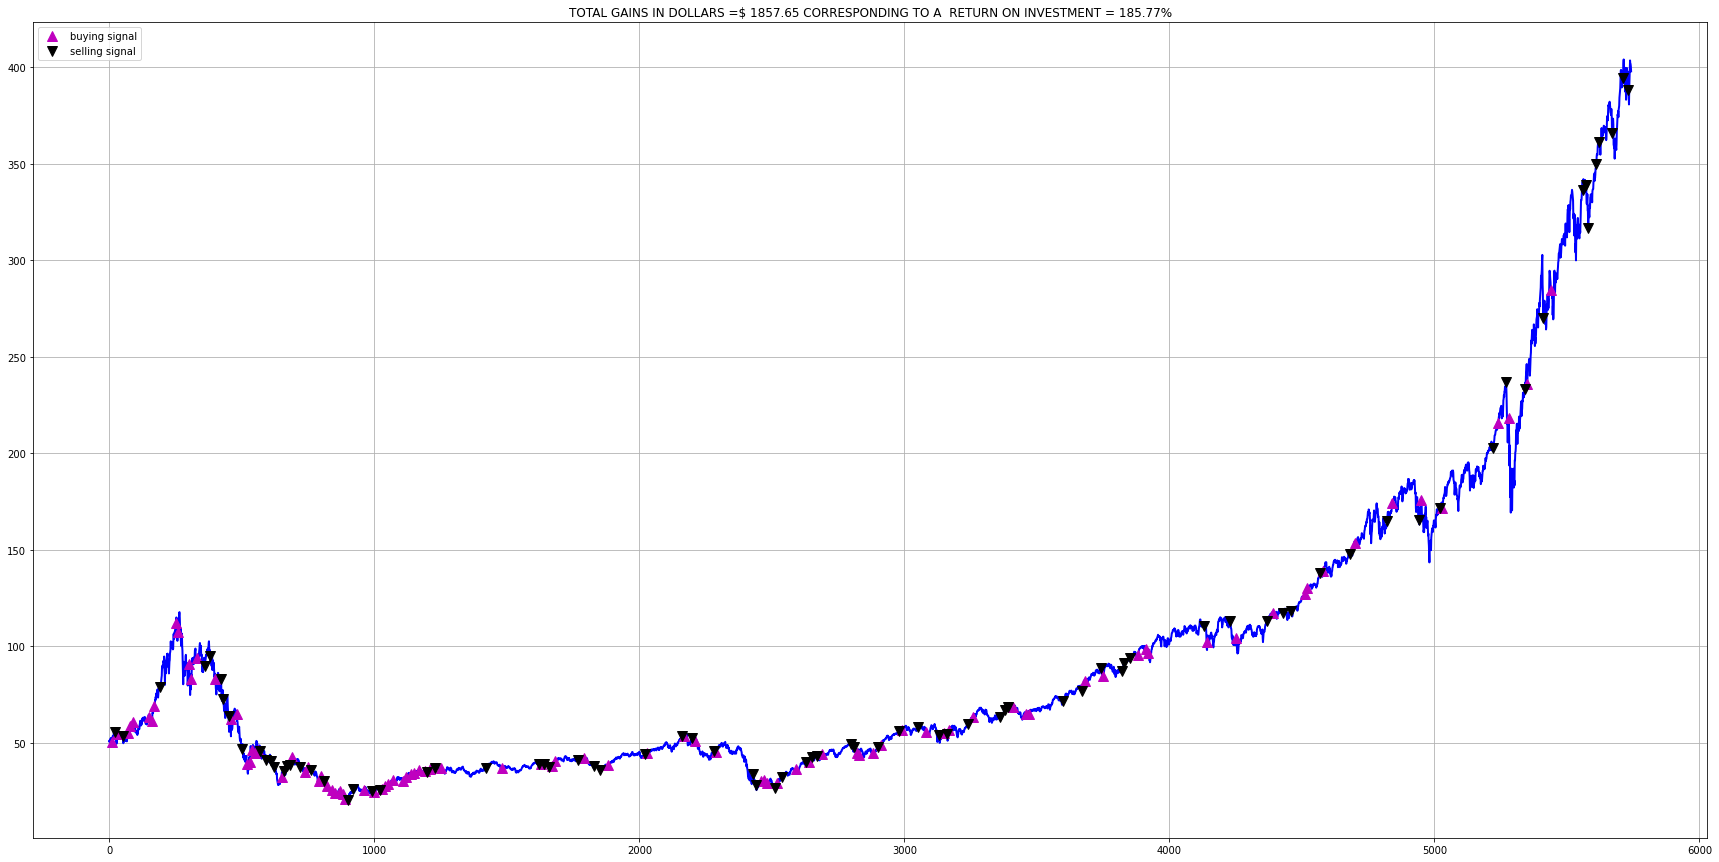

In [ ]:
close = df['Close']
fig = plt.figure(figsize = (30,15))
plt.plot(close, color='b', lw=2.)
plt.plot(close, '^', markersize=10, color='m', label = 'buying signal', markevery = states_buy)
plt.plot(close, 'v', markersize=10, color='k', label = 'selling signal', markevery = states_sell)
plt.title('TOTAL GAINS IN DOLLARS =$ %.2f CORRESPONDING TO A  RETURN ON INVESTMENT = %.2f%%'%(total_gains, invest))
plt.grid()
plt.legend()
plt.show()

## 7.CONCLUSIONS

ABSOLUTE RETURNS

OUR MODEL SEEMS TO BRING DISAPPOINTING RESULTS.

INCREASE IN THE VALUE OF THE INDEX

In [ ]:
(close[len(close)-1] - close[0])

346.7875061035156

INCREASE IN THE VALUE OF THE POSITION

In [ ]:
total_gains

1857.6528701782227